In [1]:
# Importing modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Setting up the path to include the parent directory
sys.path.append(str(Path.cwd().parent.parent))
from backend.config.settings import PATHS
from backend.scraping.scrape_reservoirs import get_reservoir_province_rate_limited

In [30]:
water_path = PATHS['cleaned_data_notebooks']/ 'water_cleaned.parquet'
water_non_merged_pd = pd.read_parquet(water_path)
water_non_merged_pd.head()

,date,storage,id,storage_imputed
0,1988-01-05,103,1,0
1,1988-01-12,103,1,0
2,1988-01-19,103,1,0
3,1988-01-26,103,1,0
4,1988-02-02,103,1,0


In [3]:
reservoirs_path = PATHS['processed_data_notebooks'] / 'post_cleaning' / 'reservoirs_cleaned.csv'
reservoirs_pd = pd.read_csv(reservoirs_path)
reservoirs_pd.head()

,id,scope,name,capacity,electric_flag
0,1,guadalquivir,brena,103.0,0
1,3,guadalquivir,fernandina,247.0,0
2,5,guadalquivir,puebla cazalla,87.0,0
3,6,guadalquivir,pedro marin,19.0,0
4,9,cuenca mediterranea andaluza,vinuela,170.0,0


In [4]:
detailed_reservoirs_path = PATHS['processed_data_notebooks'] / 'post_cleaning' / 'detailed_reservoirs_cleaned.csv'
detailed_reservoirs_pd = pd.read_csv(detailed_reservoirs_path)
detailed_reservoirs_pd.head()

,code,name,reservoir,longitude,latitude,basin,riverbed,google,openstreetmap,wikidata,province,autonomous_community,type,crest_elevation,dam_height,report
0,9220021,canelles,canelles reservoir,41.978556,0.612326,ebro,rio noguera ribagorcana,NaN,NaN,https://www.wikidata.org/wiki/Q1033116,huesca,aragon,presa fabrica boveda,508.0,151.0,https://sig.mapama.gob.es/WebServices/clientew...
1,1320044,portas,portas,42.114438,-7.209227,mino sil,rio camba,NaN,NaN,NaN,ourense,galicia,presa fabrica boveda,886.0,141.0,https://sig.mapama.gob.es/WebServices/clientew...
2,8460010,tous,tous,39.132013,-0.651384,jucar,rio jucar,NaN,NaN,NaN,valència valencia,comunitat valenciana,presa materiales sueltos zonificada o nucleo,162.5,135.5,https://sig.mapama.gob.es/WebServices/clientew...
3,10170012,susqueda,susqueda reservoir,41.979226,2.526874,cuencas internas cataluna,riu ter,NaN,NaN,https://www.wikidata.org/wiki/Q7131953,girona,cataluna,presa fabrica boveda,357.0,135.0,https://sig.mapama.gob.es/WebServices/clientew...
4,1270005,belesar,belesar reservoir,42.628777,-7.712394,mino sil,rio mino,https://www.google.com/search?kgmid=/g/1214fx9h,NaN,https://www.wikidata.org/wiki/Q3375700,lugo,galicia,presa fabrica boveda,332.0,132.0,https://sig.mapama.gob.es/WebServices/clientew...


### Create the merged dataframe from reservoirs, with even the non-matching entries

In [6]:
merged_pd = pd.merge(reservoirs_pd, detailed_reservoirs_pd, on='name', how='outer')
not_paired_reservoirs = merged_pd[(merged_pd['id'].isnull()) | (merged_pd['longitude'].isnull())]['name'].copy()
not_paired_reservoirs.sort_values(inplace=True)

#### Let's display all not paired reservoirs:

In [7]:
pd.set_option('display.max_rows', None)
not_paired_reservoirs

1              agavanzal  nª sª
2                         agrio
3           agrio (aznalcollar)
7                       aguilar
8                aguilar campoo
12                       albina
13                   alcala rio
14            alcaniz (estanca)
15                    alcantara
16                   alcollarin
19                   alfilorios
22                    algeciras
23            algeciras  rambla
28               alsa   mediajo
29                  alsa torina
32                   anchuricas
36                        arcos
37               arcos frontera
46             bachimana (lago)
47               bachimana alto
49                        banos
50             banos montemayor
51                          bao
54                        barca
59                     bautista
60                bayco  rambla
65                    benageber
67                      beninar
70                     boadella
76              bramatuero alto
77                        brena
78      

#### Number of already paired reservoirs:

In [11]:
paired_reservoirs = merged_pd[(merged_pd['id'].notnull()) & (merged_pd['longitude'].notnull())]['name'].copy()
paired_reservoirs.sort_values(inplace=True)
print(f"The number of already paired reservoirs is: {len(paired_reservoirs)}")
print(f"Remember that reservoirs_pd has {len(reservoirs_pd)} rows and detailed_reservoirs_pd has {len(detailed_reservoirs_pd)} rows")

The number of already paired reservoirs is: 273
Remember that reservoirs_pd has 401 rows and detailed_reservoirs_pd has 320 rows


#### As detailed_reservoirs_pd has less reservoirs, we will focus on its not paired ones

In [ ]:
not_paired_from_detailed = merged_pd[merged_pd['id'].isnull()]['name'].copy()
not_paired_from_detailed.sort_values(inplace=True)
not_paired_from_detailed

2                         agrio
8                aguilar campoo
23            algeciras  rambla
29                  alsa torina
36                        arcos
47               bachimana alto
50             banos montemayor
59                     bautista
60                bayco  rambla
82                       bujeda
85                    burguillo
92                  caldas reis
97               campos paraiso
108                    caspe ii
112               castrelo mino
127                   chandreja
152            darnius boadella
167                      ferial
187                     grado i
191                 guadalhorce
195                  guadalteba
197                   guadiloba
209                     ibon ip
218                       jerte
220               jose bautista
222                  juan benet
223                  lago negro
226                     lebrija
238            malpasillo jauja
239                   malvecino
241             manzanares real
244     

In [13]:
pd.reset_option('display.max_rows')

The correspondence between reservoirs is developed in the cleaning merges.ipynb notebook

### Looking for possible inconsistencies between dataframes

Reading the dataframe developed at the cleaning file

In [31]:
reservoirs_path = PATHS['pre_EDA']/ 'merges_for_EDA.csv'
reservoirs_pd = pd.read_csv(reservoirs_path)
reservoirs_pd.head()

,id,scope,name,capacity,electric_flag,longitude,latitude,basin,riverbed,google,openstreetmap,wikidata,province,autonomous_community,type,crest_elevation,dam_height,report
0,1,guadalquivir,brena,103.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cordoba,andalucia,NaN,NaN,NaN,NaN
1,3,guadalquivir,fernandina,247.0,0,38.179646,-3.570224,guadalquivir,rio guarrizas,NaN,NaN,NaN,jaen,andalucia,presa fabrica gravedad (hormigon vibrado),719.55,NaN,https://sig.mapama.gob.es/WebServices/clientew...
2,5,guadalquivir,puebla cazalla,87.0,0,37.129772,-5.243309,guadalquivir,rio corbones,NaN,NaN,NaN,sevilla,andalucia,presa fabrica gravedad (hormigon compactado),218.25,NaN,https://sig.mapama.gob.es/WebServices/clientew...
3,6,guadalquivir,pedro marin,19.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,jaen,andalucia,NaN,NaN,NaN,NaN
4,9,cuenca mediterranea andaluza,vinuela,170.0,0,36.860400,-4.164435,cuencas mediterraneas andaluzas,rio guaro,https://www.google.com/search?kgmid=/g/120jr2sh,NaN,https://www.wikidata.org/wiki/Q5830515,malaga,andalucia,presa materiales sueltos pantalla hormigon,426.00,NaN,https://sig.mapama.gob.es/WebServices/clientew...


Merging them

In [33]:
water_pd = pd.merge(water_non_merged_pd, reservoirs_pd[['id', 'capacity', 'crest_elevation', 'province', 'autonomous_community']], on='id', how='left')
water_pd.head()

,date,storage,id,storage_imputed,capacity,crest_elevation,province,autonomous_community
0,1988-01-05,103,1,0,103.0,NaN,cordoba,andalucia
1,1988-01-12,103,1,0,103.0,NaN,cordoba,andalucia
2,1988-01-19,103,1,0,103.0,NaN,cordoba,andalucia
3,1988-01-26,103,1,0,103.0,NaN,cordoba,andalucia
4,1988-02-02,103,1,0,103.0,NaN,cordoba,andalucia


### Looking for reservoirs with higher storage than capacity

In [21]:
water_pd[water_pd['storage'] > water_pd['capacity']]

,date,storage,id,storage_imputed,capacity,crest_elevation,province,autonomous_community,storage_higher_than_capacity
102,1989-12-19,107,1,0,103,NaN,cordoba,andalucia,True
106,1990-01-16,104,1,0,103,NaN,cordoba,andalucia,True
109,1990-02-06,104,1,0,103,NaN,cordoba,andalucia,True
36113,1991-06-18,55,46,0,54,443.50,teruel,aragon,True
55096,1989-11-21,62,69,0,60,10.34,huelva,andalucia,True
...,...,...,...,...,...,...,...,...,...
629448,1994-01-11,182,678,0,181,662.12,salamanca,castilla y leon,True
629504,1995-02-07,182,678,0,181,662.12,salamanca,castilla y leon,True
649787,1991-04-30,9,714,0,8,NaN,huelva,andalucia,True
649815,1991-11-12,9,714,0,8,NaN,huelva,andalucia,True


### Show a barplot with the proportion of reservoirs with storage higher than capacity

In [27]:
higher_count = water_pd[water_pd['storage'] > water_pd['capacity']]['id'].nunique()
valid_count = water_pd[water_pd['storage'] <= water_pd['capacity']]['id'].nunique()

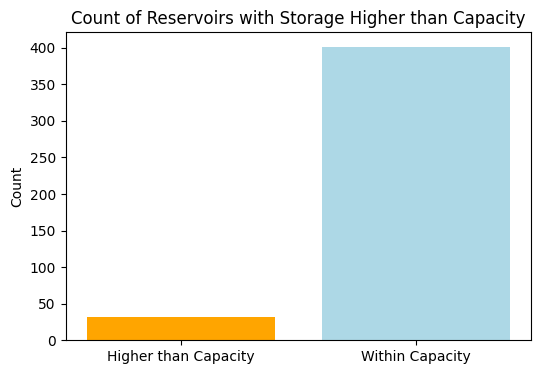

In [29]:
plt.figure(figsize=(6, 4))
plt.bar(['Higher than Capacity', 'Within Capacity'], [higher_count, valid_count], color=['orange', 'lightblue'])
plt.title('Count of Reservoirs with Storage Higher than Capacity')
plt.ylabel('Count')
plt.show()

This problem will be tackled setting the storage of the reservoirs that are over capacity to their capacity value

### Looking for reservoirs that don't have data up to date

In [34]:
max_date = water_pd['date'].max()
print(f"The maximum date in the water dataframe is {max_date}.")

The maximum date in the water dataframe is 2024-09-24 00:00:00.


### Graphic to see the proportion of reservoirs with and without data up to date

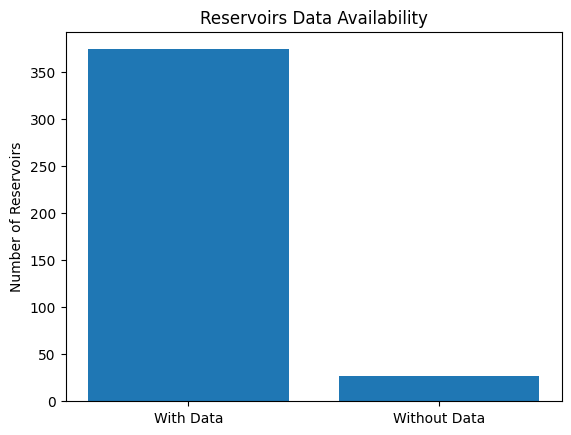

In [37]:
reservoirs_with_data = water_pd[water_pd['date'] == max_date]
reservoirs_without_data = reservoirs_pd[~reservoirs_pd['id'].isin(reservoirs_with_data['id'])]

plt.bar(['With Data', 'Without Data'], [reservoirs_with_data['id'].nunique(), reservoirs_without_data['id'].nunique()])
plt.title('Reservoirs Data Availability')
plt.ylabel('Number of Reservoirs')
plt.show()